In [ ]:
!pip install transformers datasets evaluate accelerate scikit-learn pandas torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate

def compute_metrics(eval_pred):
    metric_acc = evaluate.load("accuracy")
    metric_f1 = evaluate.load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]

    return {"accuracy": accuracy, "f1": f1}

# 1. Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Using device: {device.upper()} (If this says CPU, stop and change runtime!)")

# 2. Load Data
print("🚀 Loading fully labeled dataset for Transformer...")
df = pd.read_csv('fully_labeled_dataset.csv') # Colab path
df['label'] = df['label'].astype(int)
df['text'] = df['text'].astype(str)

# 3. Shuffle & Split Data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(0.8 * len(df))
val_size = int(0.1 * len(df))

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

print(f"📊 Data Split -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# 4. Convert to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# 5. Load Tokenizer & Model
model_name = "xlm-roberta-base"
print(f"🤖 Loading Tokenizer & Model: {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("✂️ Tokenizing datasets...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# 6. Set Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Updated for newest transformers version
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir='./logs',
    logging_steps=50,
    fp16=True, # 🔥 This makes it train 2x faster on GPU!
)

# 7. Train!
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("🔥 Starting Training! Grab a coffee...")
trainer.train()

# 8. Evaluate on unseen Test Data
print("\n🏆 Evaluating on completely unseen TEST set...")
test_results = trainer.evaluate(tokenized_test)
print("FINAL TEST METRICS:")
print(test_results)

🖥️ Using device: CUDA (If this says CPU, stop and change runtime!)
🚀 Loading fully labeled dataset for Transformer...
📊 Data Split -> Train: 5639 | Val: 704 | Test: 706
🤖 Loading Tokenizer & Model: xlm-roberta-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


🏆 Evaluating on completely unseen TEST set...


FINAL TEST METRICS:
{'eval_loss': 0.6631471514701843, 'eval_accuracy': 0.7379603399433428, 'eval_f1': 0.7324238481230679, 'eval_runtime': 3.8327, 'eval_samples_per_second': 184.206, 'eval_steps_per_second': 11.741, 'epoch': 3.0}


🔍 Running Error Analysis on Test Data...


❌ The model made 185 mistakes out of 706 test samples.
💾 Saved mistakes to 'transformer_mistakes.csv'. Download this from the left sidebar!
📊 Confusion Matrix saved as 'confusion_matrix.png'. Download it!


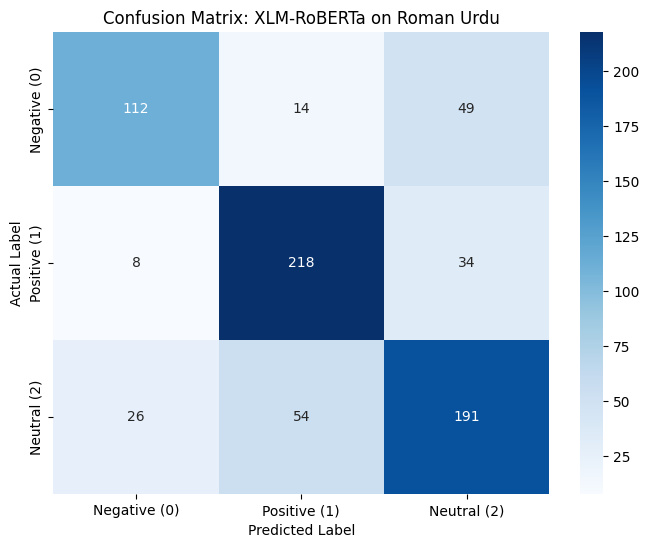

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🔍 Running Error Analysis on Test Data...")

# 1. Get predictions from the model
predictions = trainer.predict(tokenized_test)
predicted_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# 2. Extract the actual text for the test set
test_texts = test_df['text'].tolist()

# 3. Create a DataFrame to see where the model failed
error_df = pd.DataFrame({
    'text': test_texts,
    'true_label': true_labels,
    'predicted_label': predicted_labels
})

# Filter only the wrong predictions
mistakes_df = error_df[error_df['true_label'] != error_df['predicted_label']]

print(f"❌ The model made {len(mistakes_df)} mistakes out of {len(test_df)} test samples.")

# Save to CSV so you can download and analyze it!
mistakes_df.to_csv('transformer_mistakes.csv', index=False)
print("💾 Saved mistakes to 'transformer_mistakes.csv'. Download this from the left sidebar!")

# 4. Draw a beautiful Confusion Matrix for your Research Paper!
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)', 'Neutral (2)'],
            yticklabels=['Negative (0)', 'Positive (1)', 'Neutral (2)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix: XLM-RoBERTa on Roman Urdu')
plt.savefig('confusion_matrix.png', dpi=300) # Saves high-res image for paper
print("📊 Confusion Matrix saved as 'confusion_matrix.png'. Download it!")
plt.show()